In [1]:
import pandas as pd
from tensorflow import keras
import tensorflow as tf
import numpy as np
import os

from datetime import datetime
from sklearn.preprocessing import MinMaxScaler

from keras.optimizers import Adam
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras import callbacks

from imblearn.over_sampling import SMOTE
from collections import Counter

In [2]:
os.environ['TF_CPP_MIN_LOG_LEVEL']='2'

In [3]:
df=pd.read_csv("cleaned_dataset_taiwan_2months.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125914 entries, 0 to 125913
Data columns (total 14 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   date      125914 non-null  object 
 1   sitename  125914 non-null  object 
 2   county    125914 non-null  object 
 3   aqi       125914 non-null  float64
 4   status    125914 non-null  object 
 5   so2       125914 non-null  float64
 6   co        125914 non-null  float64
 7   o3        125914 non-null  float64
 8   pm10      125914 non-null  float64
 9   pm2.5     125914 non-null  float64
 10  no2       125914 non-null  float64
 11  nox       125914 non-null  float64
 12  no        125914 non-null  float64
 13  siteid    125914 non-null  int64  
dtypes: float64(9), int64(1), object(4)
memory usage: 13.4+ MB


In [4]:
to_numeric_column=["aqi",'so2','co','o3','pm2.5','pm10','no2','nox','no','siteid']
df[to_numeric_column]=df[to_numeric_column].apply(pd.to_numeric, errors='coerce')
df[to_numeric_column] = df[to_numeric_column].ffill().bfill()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125914 entries, 0 to 125913
Data columns (total 14 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   date      125914 non-null  object 
 1   sitename  125914 non-null  object 
 2   county    125914 non-null  object 
 3   aqi       125914 non-null  float64
 4   status    125914 non-null  object 
 5   so2       125914 non-null  float64
 6   co        125914 non-null  float64
 7   o3        125914 non-null  float64
 8   pm10      125914 non-null  float64
 9   pm2.5     125914 non-null  float64
 10  no2       125914 non-null  float64
 11  nox       125914 non-null  float64
 12  no        125914 non-null  float64
 13  siteid    125914 non-null  int64  
dtypes: float64(9), int64(1), object(4)
memory usage: 13.4+ MB


In [5]:
df['date']=pd.to_datetime(df['date'])
df.head()

,date,sitename,county,aqi,status,so2,co,o3,pm10,pm2.5,no2,nox,no,siteid
0,2024-08-31 23:00:00,Hukou,Hsinchu County,62.0,Moderate,0.9,0.17,35.0,18.0,17.0,2.3,2.6,0.3,22
1,2024-08-31 23:00:00,Zhongming,Taichung City,50.0,Good,1.6,0.32,27.9,27.0,14.0,7.6,9.3,1.6,31
2,2024-08-31 23:00:00,Zhudong,Hsinchu County,45.0,Good,0.4,0.17,25.1,21.0,13.0,2.9,4.1,1.1,23
3,2024-08-31 23:00:00,Hsinchu,Hsinchu City,42.0,Good,0.8,0.20,30.0,19.0,10.0,4.0,4.8,0.7,24
4,2024-08-31 23:00:00,Toufen,Miaoli County,50.0,Good,1.0,0.16,33.5,18.0,14.0,1.8,3.1,1.2,25


In [6]:
df.head()

,date,sitename,county,aqi,status,so2,co,o3,pm10,pm2.5,no2,nox,no,siteid
0,2024-08-31 23:00:00,Hukou,Hsinchu County,62.0,Moderate,0.9,0.17,35.0,18.0,17.0,2.3,2.6,0.3,22
1,2024-08-31 23:00:00,Zhongming,Taichung City,50.0,Good,1.6,0.32,27.9,27.0,14.0,7.6,9.3,1.6,31
2,2024-08-31 23:00:00,Zhudong,Hsinchu County,45.0,Good,0.4,0.17,25.1,21.0,13.0,2.9,4.1,1.1,23
3,2024-08-31 23:00:00,Hsinchu,Hsinchu City,42.0,Good,0.8,0.20,30.0,19.0,10.0,4.0,4.8,0.7,24
4,2024-08-31 23:00:00,Toufen,Miaoli County,50.0,Good,1.0,0.16,33.5,18.0,14.0,1.8,3.1,1.2,25


In [7]:
def model_train(input_shape):
    model=keras.models.Sequential()

    model.add(keras.layers.Input(shape=input_shape))

   # model.add(keras.layers.LSTM(254,return_sequences=True))
    #model.add(keras.layers.Dropout(0.5))

    model.add(keras.layers.LSTM(128,return_sequences=True))
    model.add(keras.layers.Dropout(0.4))
    
    model.add(keras.layers.LSTM(64,return_sequences=False))
    model.add(keras.layers.Dropout(0.3))
    
    model.add(keras.layers.Dense(32,activation="relu"))
    model.add(keras.layers.Dense(1))
    

    return model

In [8]:
n_windows=100
scaler=MinMaxScaler(feature_range=(0,1))



feature_cols=['aqi','so2','co','o3','pm2.5','pm10','no2','nox','no']
df[feature_cols] = scaler.fit_transform(df[feature_cols])


In [9]:




X_train,y_train=[],[]
X_test_all, y_test_all = [], []

for station, group in df.groupby('sitename'):
    # Ensure the timeline within the station is sorted chronologically
    group = group.sort_values('date')
    station_data = group[feature_cols].values
    
    # Calculate train/test split index for this specific station (80/20 split)
    train_len = int(np.ceil(len(station_data) * 0.80))
    
    # Generate Training Windows for this station
    for i in range(n_windows, train_len):
        X_train.append(station_data[i-n_windows:i])
        y_train.append(station_data[i, 0]) # Index 0 is 'aqi'
        
    # Generate Testing Windows for this station
    for i in range(train_len, len(station_data)):
        X_test_all.append(station_data[i-n_windows:i])  
        y_test_all.append(station_data[i, 0])

X_train, y_train = np.array(X_train), np.array(y_train)
X_test_all, y_test_all = np.array(X_test_all), np.array(y_test_all)
model = model_train(input_shape=(X_train.shape[1], X_train.shape[2]))

In [10]:
print(X_train.shape)

(92280, 100, 9)


In [11]:
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=3, 
    min_lr=1e-6
)

my_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    callbacks.ModelCheckpoint(filepath='best_model_lstm_regressor.keras', monitor='val_loss', save_best_only=True),
    reduce_lr
]

In [12]:
model.compile(
            optimizer=Adam(learning_rate=0.0005),
            loss="mae",  #mae
            metrics=[
 "mae","mse"
    ])

model.fit(X_train, y_train, epochs=50, batch_size=128, shuffle=True,verbose=1,callbacks=my_callbacks,validation_split=0.2)

Epoch 1/50
577/577 ━━━━━━━━━━━━━━━━━━━━ 153s 258ms/step - loss: 0.0320 - mae: 0.0320 - mse: 0.0022 - val_loss: 0.0197 - val_mae: 0.0197 - val_mse: 8.0983e-04 - learning_rate: 5.0000e-04
Epoch 2/50
577/577 ━━━━━━━━━━━━━━━━━━━━ 147s 255ms/step - loss: 0.0197 - mae: 0.0197 - mse: 7.9661e-04 - val_loss: 0.0148 - val_mae: 0.0148 - val_mse: 5.0722e-04 - learning_rate: 5.0000e-04
Epoch 3/50
577/577 ━━━━━━━━━━━━━━━━━━━━ 152s 263ms/step - loss: 0.0162 - mae: 0.0162 - mse: 5.7479e-04 - val_loss: 0.0130 - val_mae: 0.0130 - val_mse: 4.5686e-04 - learning_rate: 5.0000e-04
Epoch 4/50
577/577 ━━━━━━━━━━━━━━━━━━━━ 149s 258ms/step - loss: 0.0151 - mae: 0.0151 - mse: 5.2137e-04 - val_loss: 0.0123 - val_mae: 0.0123 - val_mse: 4.2811e-04 - learning_rate: 5.0000e-04
Epoch 5/50
577/577 ━━━━━━━━━━━━━━━━━━━━ 148s 256ms/step - loss: 0.0145 - mae: 0.0145 - mse: 4.9855e-04 - val_loss: 0.0120 - val_mae: 0.0120 - val_mse: 4.0826e-04 - learning_rate: 5.0000e-04
Epoch 6/50
577/577 ━━━━━━━━━━━━━━━━━━━━ 139s 242ms/ste

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
best_model=tf.keras.models.load_model("best_model_lstm_regressor.keras")


X_test_all = np.array(X_test_all)
y_test_all = np.array(y_test_all)

# 2. Generate Predictions
predictions_scaled = best_model.predict(X_test_all, verbose=0)

# 3. Inverse Scale the Predictions
dummy = np.zeros((len(predictions_scaled), 9))
dummy[:, 0] = predictions_scaled.flatten()
predictions_all = scaler.inverse_transform(dummy)[:, 0]

dummy_true = np.zeros((len(y_test_all), 9))
dummy_true[:, 0] = y_test_all
y_test_all = scaler.inverse_transform(dummy_true)[:, 0]

# 4. Calculate Final Global Metrics
global_mae = mean_absolute_error(y_test_all, predictions_all)
global_rmse = np.sqrt(mean_squared_error(y_test_all, predictions_all))
global_r2 = r2_score(y_test_all, predictions_all)

print("--- Overall Model Performance (Test Set) ---")
print(f"Global R-squared (R2): {global_r2:.4f}")
print(f"Global Mean Absolute Error (MAE): {global_mae:.2f} AQI points")
print(f"Global Root Mean Squared Error (RMSE): {global_rmse:.2f} AQI points")



--- Overall Model Performance (Test Set) ---
Global R-squared (R2): 0.9715
Global Mean Absolute Error (MAE): 1.58 AQI points
Global Root Mean Squared Error (RMSE): 2.58 AQI points


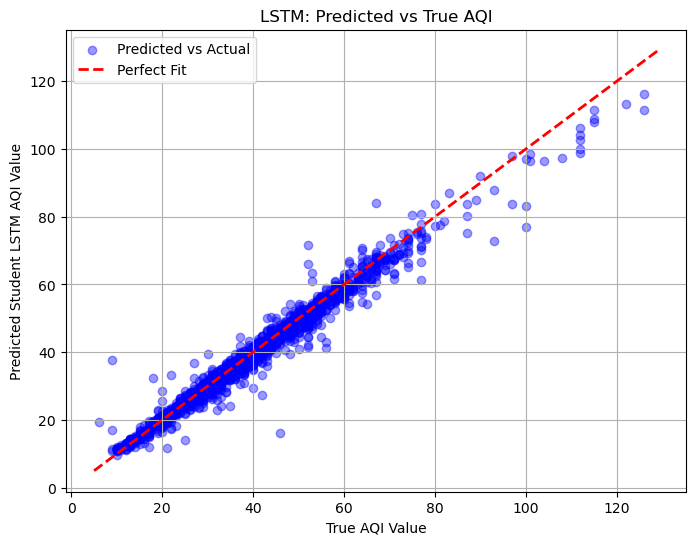

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.scatter(y_test_all[:2000], predictions_all[:2000], alpha=0.4, color='b', label='Predicted vs Actual')

# Plot accurate perfect diagonal trendline boundary
perfect_line = [min(y_test_all), max(y_test_all)]
plt.plot(perfect_line, perfect_line, color='red', linestyle='--', linewidth=2, label='Perfect Fit')

plt.xlabel('True AQI Value')
plt.ylabel('Predicted Student LSTM AQI Value')
plt.title('LSTM: Predicted vs True AQI')
plt.legend()
plt.grid(True)
plt.savefig('LSTM_fit.png')

--- Classification Report ---
                                precision    recall  f1-score   support

                          Good       0.98      0.98      0.98     20129
                      Moderate       0.93      0.91      0.92      4945
Unhealthy for Sensitive Groups       0.93      0.65      0.76        60

                      accuracy                           0.97     25134
                     macro avg       0.95      0.85      0.89     25134
                  weighted avg       0.97      0.97      0.97     25134



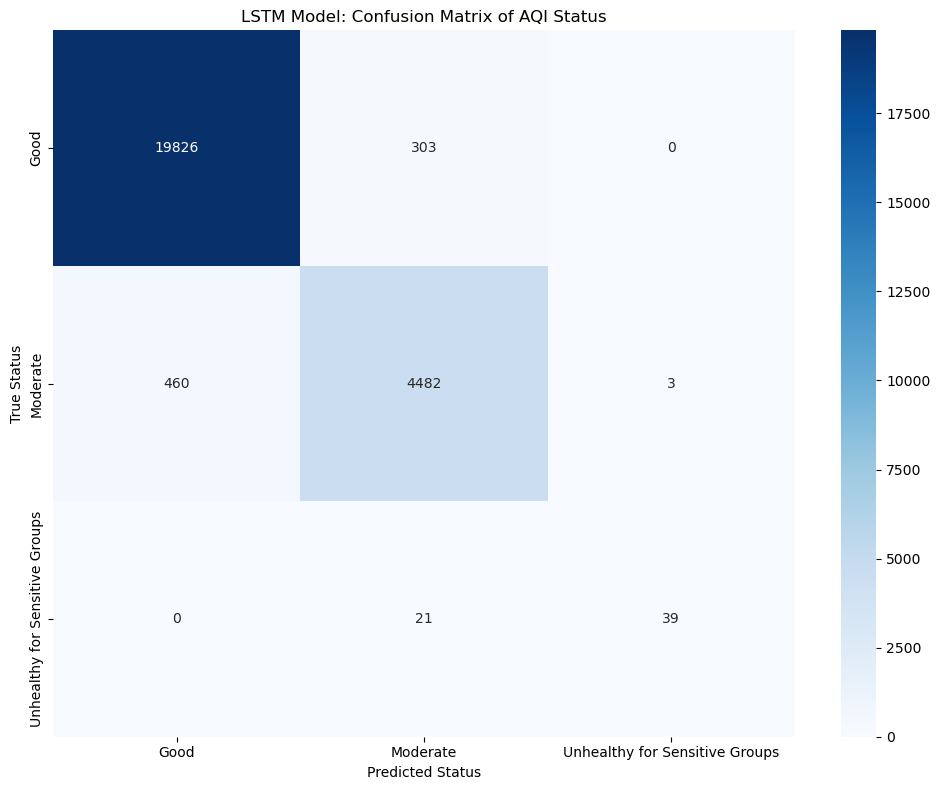

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_recall_fscore_support




# 1. Define a function to map the unscaled AQI values to their official status categories
def aqi_to_status(aqi_value):
    if aqi_value <= 50:
        return 'Good'
    elif aqi_value <= 100:
        return 'Moderate'
    elif aqi_value <= 150:
        return 'Unhealthy for Sensitive Groups'
    elif aqi_value <= 200:
        return 'Unhealthy'
    elif aqi_value <= 300:
        return 'Very Unhealthy'
    else:
        return 'Hazardous'

# 2. Convert continuous predicted AQI values into status labels
pred_statuses = [aqi_to_status(val) for val in predictions_all]

# 3. Extract the exact true status labels for the test set from the original dataframe
y_test_status_all = []
for station, group in df.groupby('sitename'):
    group = group.sort_values('date')
    train_len = int(np.ceil(len(group) * 0.80))
    # Collect chronological status strings for the 20% test partition
    for i in range(train_len, len(group)):
        y_test_status_all.append(group.iloc[i]['status'])

# 4. Define chronological order for categories to display logically in the matrix
all_possible_labels = ['Good', 'Moderate', 'Unhealthy for Sensitive Groups', 'Unhealthy', 'Very Unhealthy', 'Hazardous']
# Keep only labels that actually appear in the test dataset to avoid empty columns/rows
ordered_labels = [label for label in all_possible_labels if (label in y_test_status_all or label in pred_statuses)]

# 5. Compute the confusion matrix and print precision, recall, and F1-score
cm = confusion_matrix(y_test_status_all, pred_statuses, labels=ordered_labels)

print("--- Classification Report ---")
print(classification_report(y_test_status_all, pred_statuses, labels=ordered_labels))

# 6. Plot and save the Confusion Matrix as a Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=ordered_labels, yticklabels=ordered_labels)
plt.xlabel('Predicted Status')
plt.ylabel('True Status')
plt.title('LSTM Model: Confusion Matrix of AQI Status')
plt.tight_layout()
plt.savefig('LSTM_confusion_matrix.png')
plt.show()

In [20]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# 1. Map the true unscaled continuous AQI values to their string status categories
y_test_status_ground_truth = [aqi_to_status(val) for val in y_test_all]

# 2. Calculate the classification metrics using both categorical string lists
accuracy = accuracy_score(y_test_status_ground_truth, pred_statuses)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test_status_ground_truth, 
    pred_statuses,              # Fixed: changed from predictions_all to pred_statuses
    average='weighted'
)

print("--- Overall Categorical Performance (Global) ---")
print(f"Accuracy:  {accuracy:.2%}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

--- Overall Categorical Performance (Global) ---
Accuracy:  96.87%
Precision: 0.9684
Recall:    0.9687
F1-Score:  0.9684
